# Lab 9: PCA on Allen Neuropixels Population Activity

#### Stephen Spivack, CDS Adjunct, Fall 2025

You will learn to:

1. Construct a population spike matrix
(neurons × time bins)

2. Normalize spiking activity (z-scoring)

3. Compute the principal components using scikit-learn

4. Visualize:

 - the scree plot of eigenvalues

 - the cumulative explained variance

These analyses reveal how large neural populations evolve over time and help uncover low-dimensional structure underlying behavior, sensory responses, and global brain state.


Using the Allen SDK to retrieve data

This lab was adapted directly from Allen: https://allensdk.readthedocs.io/en/latest/_static/examples/nb/ecephys_data_access.html

The data come from the Allen Brain Observatory Neuropixels Visual Coding (2019) experiment, where awake, head-fixed mice were recorded with high-density Neuropixels probes while they passively viewed visual stimuli. Each session includes hundreds of simultaneously recorded neurons across many brain regions, and the mice were shown a standardized battery of stimuli: drifting gratings, static gratings, natural images, repeated natural movies, long continuous movies, and periods of spontaneous activity. No behavioral task was required — the mouse simply sat on a running wheel — so the dataset captures both stimulus-evoked responses and rich spontaneous population dynamics, making it ideal for PCA and other population-level analyses.

Import libraries

In [17]:
import os
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

prepare the cache to download the following metadata files:

 - sessions.csv (7.8 kB)
 - probes.csv (27.0 kB)
 - channels.csv (6.6 MB)
 - units.csv (51.4 MB)

In [2]:
output_dir = os.getcwd() # you can manually specify a filepath if you prefer
print(output_dir) # print it
manifest_path = os.path.join(output_dir, "manifest.json") # specify the location of the manifest file
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path) # create the cache object

/Users/sspivack/Desktop/nds2025/data/lab9_allen_neuropixels


### Overview of metadata

The sessions DataFrame provides a high-level overview of the Neuropixels Visual Coding dataset. The index column is a unique ID, which serves as a key for accessing the physiology data for each session. The other columns contain information about:

 - the session type (i.e., which stimulus set was shown?)
 - the age, sex, and genotype of the mouse (in this dataset, there's only one session per mouse)
 - the number of probes, channels, and units for each session
 - the brain structures recorded (CCFv3 acronyms)

In [3]:
sessions = cache.get_session_table()
print('Total number of sessions: ' + str(len(sessions)))
sessions.head()

Total number of sessions: 58


,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


The probes DataFrame contains information about the Neuropixels probes used across all recordings. Each row represents one probe from one recording session, even though the physical probes may have been used in multiple sessions. Some of the important columns are:

 - ecephys_session_id: the index column of the sessions table
 - sampling_rate: the sampling rate (in Hz) for this probe's spike band; note that each probe has a unique sampling rate around 30 kHz. The small variations in sampling rate across probes can add up to large offsets over time, so it's critical to take these differences into account. However, all of the data you will interact with has been pre-aligned to a common clock, so this value is included only for reference purposes.
 - lfp_sampling_rate: the sampling rate (in Hz) for this probe's LFP band NWB files, after 2x downsampling from the original rate of 2.5 kHz
 - name: the probe name is assigned based on the location of the probe on the recording rig. This is useful to keep in mind because probes with the same name are always targeted to the same cortical region and enter the brain from the same angle (probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL). However, the targeting is not always accurate, so the actual recorded region may be different.
 - phase: the data may have been generated by one of two "phases" of Neuropixels probes. 3a = prototype version; PXI = publicly available version ("Neuropixels 1.0"). The two phases should be equivalent from the perspective of data analysis, but there may be differences in the noise characteristics between the two acquisition systems.
 - channel_count: the number of channels with spikes or LFP data (maximum = 384)

In [4]:
probes = cache.get_probes()
print('Total number of probes: ' + str(len(probes)))
probes.head()

Total number of probes: 332


,ecephys_session_id,lfp_sampling_rate,name,phase,sampling_rate,has_lfp_data,unit_count,channel_count,ecephys_structure_acronyms
id,,,,,,,,,
729445648,719161530,1249.998642,probeA,3a,29999.967418,True,87,374,"[APN, LP, MB, DG, CA1, VISam, nan]"
729445650,719161530,1249.996620,probeB,3a,29999.918880,True,202,368,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan]"
729445652,719161530,1249.999897,probeC,3a,29999.997521,True,207,373,"[APN, NOT, MB, DG, SUB, VISp, nan]"
729445654,719161530,1249.996707,probeD,3a,29999.920963,True,93,358,"[grey, VL, CA3, CA2, CA1, VISl, nan]"
729445656,719161530,1249.999979,probeE,3a,29999.999500,True,138,370,"[PO, VPM, TH, LP, LGd, CA3, DG, CA1, VISal, nan]"


The channels.csv file contains information about each of these channels.

The most important columns in the channels DataFrame concern each channel's location in physical space. Each channel is associated with a location along the probe shank (probe_horizontal_position and probe_vertical_position), and may be linked to a coordinate in the Allen Common Coordinate framework (if CCF registration is available for that probe).

The information about channel location will be merged into the units DataFrame, which is loaded from units.csv

In [5]:
channels = cache.get_channels()
print('Total number of channels: ' + str(len(channels)))
channels.head()

Total number of channels: 123224


,ecephys_probe_id,local_index,probe_horizontal_position,probe_vertical_position,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,left_right_ccf_coordinate,ecephys_structure_id,ecephys_structure_acronym,ecephys_session_id,lfp_sampling_rate,phase,sampling_rate,has_lfp_data,unit_count
id,,,,,,,,,,,,,,,
849705558,792645504,1,11,20,8165.0,3314.0,6862.0,215.0,APN,779839471,1250.001479,3a,30000.035489,True,0
849705560,792645504,2,59,40,8162.0,3307.0,6866.0,215.0,APN,779839471,1250.001479,3a,30000.035489,True,0
849705562,792645504,3,27,40,8160.0,3301.0,6871.0,215.0,APN,779839471,1250.001479,3a,30000.035489,True,0
849705564,792645504,4,43,60,8157.0,3295.0,6875.0,215.0,APN,779839471,1250.001479,3a,30000.035489,True,0
849705566,792645504,5,11,60,8155.0,3288.0,6879.0,215.0,APN,779839471,1250.001479,3a,30000.035489,True,0


This DataFrame contains metadata about the available units across all sessions. By default, the AllenSDK applies some filters to this table and only returns units above a particular quality threshold.

The default filter values are as follows:

- isi_violations < 0.5
- amplitude_cutoff < 0.1
- presence_ratio > 0.9

In [6]:
units = cache.get_units()
print('Total number of units: ' + str(len(units)))

Total number of units: 40010


there are a number of stimulus-specific metrics that are computed for each unit

In [7]:
analysis_metrics1 = cache.get_unit_analysis_metrics_by_session_type('brain_observatory_1.1')

analysis_metrics2 = cache.get_unit_analysis_metrics_by_session_type('functional_connectivity')

print(str(len(analysis_metrics1)) + ' units in table 1')
print(str(len(analysis_metrics2)) + ' units in table 2')

21842 units in table 1
18168 units in table 2


### Accessing data for individual sessions

Assuming you've found a session you're interested in analyzing in more detail, it's now time to download the data. This is as simple as calling cache.get_session_data(), with the session_id as input. This method will check the cache for an existing NWB file and, if it's not present, will automatically download it for you.

Each NWB file can be upwards of 2 GB, so please be patient while it's downloading!

In [8]:
session = cache.get_session_data(sessions.index.values[0], # select session here using index
                                 isi_violations_maximum = np.inf,
                                 amplitude_cutoff_maximum = np.inf,
                                 presence_ratio_minimum = -np.inf
                                )

print([attr_or_method for attr_or_method in dir(session) if attr_or_method[0] != '_'])

Downloading:   0%|          | 0.00/2.86G [00:00<?, ?B/s]

/Users/sspivack/anaconda3/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


['DETAILED_STIMULUS_PARAMETERS', 'LazyProperty', 'age_in_days', 'api', 'channel_structure_intervals', 'channels', 'conditionwise_spike_statistics', 'ecephys_session_id', 'from_nwb_path', 'full_genotype', 'get_current_source_density', 'get_inter_presentation_intervals_for_stimulus', 'get_invalid_times', 'get_lfp', 'get_parameter_values_for_stimulus', 'get_pupil_data', 'get_screen_gaze_data', 'get_stimulus_epochs', 'get_stimulus_parameter_values', 'get_stimulus_table', 'inter_presentation_intervals', 'invalid_times', 'mean_waveforms', 'metadata', 'num_channels', 'num_probes', 'num_stimulus_presentations', 'num_units', 'optogenetic_stimulation_epochs', 'presentationwise_spike_counts', 'presentationwise_spike_times', 'probes', 'rig_equipment_name', 'rig_geometry_data', 'running_speed', 'session_start_time', 'session_type', 'sex', 'specimen_name', 'spike_amplitudes', 'spike_times', 'stimulus_conditions', 'stimulus_names', 'stimulus_presentations', 'structure_acronyms', 'structurewise_unit_c

In [9]:
units = session.units  # metadata for each unit
spike_times = session.spike_times # array of spike times (in seconds)

/Users/sspivack/anaconda3/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/Users/sspivack/anaconda3/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/Users/sspivack/anaconda3/lib/python3.11/site-pa

In [10]:
units

,waveform_PT_ratio,waveform_amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,L_ratio,...,ecephys_structure_id,ecephys_structure_acronym,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,left_right_ccf_coordinate,probe_description,location,probe_sampling_rate,probe_lfp_sampling_rate,probe_has_lfp_data
unit_id,,,,,,,,,,,,,,,,,,,,,
950910332,1.074955,120.868605,0.139006,3,389.93,4.522811,1.736711,0.101473,5.258583e+01,0.001699,...,215.0,APN,8162.0,3538.0,6694.0,probeA,See electrode locations,29999.954846,1249.998119,True
950910326,1.861119,148.358438,0.008088,2,0.00,4.345510,0.003733,0.000000,2.488905e+13,NaN,...,215.0,APN,8162.0,3538.0,6694.0,probeA,See electrode locations,29999.954846,1249.998119,True
950910319,1.800296,141.769485,0.028678,1,411.00,4.684774,12.713519,0.008115,8.244526e+01,0.000728,...,215.0,APN,8162.0,3538.0,6694.0,probeA,See electrode locations,29999.954846,1249.998119,True
950910311,0.962239,112.067475,0.500000,0,265.32,4.008943,12.550090,0.250391,5.509009e+01,0.012544,...,215.0,APN,8162.0,3538.0,6694.0,probeA,See electrode locations,29999.954846,1249.998119,True
950912689,0.526303,116.808120,0.392370,267,698.80,2.539356,0.608689,0.000000,2.490183e+01,0.021017,...,215.0,APN,8157.0,3521.0,6697.0,probeA,See electrode locations,29999.954846,1249.998119,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950957020,0.166421,88.327200,0.090464,210,426.88,3.663603,2.121668,1.151242,4.082196e+01,0.035734,...,417.0,VISrl,7286.0,979.0,8749.0,probeF,See electrode locations,30000.028033,1250.001168,True
950957004,0.238950,260.111280,0.004265,209,67.98,6.998293,0.347530,2.580927,6.729711e+01,0.000084,...,417.0,VISrl,7286.0,979.0,8749.0,probeF,See electrode locations,30000.028033,1250.001168,True
950956952,1.704987,156.687960,0.001086,207,102.27,6.071788,19.358752,0.011957,9.623880e+01,0.000349,...,417.0,VISrl,7289.0,990.0,8746.0,probeF,See electrode locations,30000.028033,1250.001168,True


Accessing the LFP data

In [11]:
#probe_id = session.probes.index.values[0]
#lfp = session.get_lfp(probe_id)

## Principal Component Analysis (PCA)

To analyze the **population structure** of simultaneously recorded neurons, we apply **Principal Component Analysis (PCA)** to a matrix of binned spike counts:

$$
X \in \mathbb{R}^{N \times T}
$$

where

- $N$ = number of neurons  
- $T$ = number of time bins  
- $X_{i,t}$ = spike count of neuron $i$ in time bin $t$

---

### 1. Z-Scoring Each Neuron

Because neurons have different firing rates and variances, we first **normalize** each neuron:

$$
Z_{i,t} = \frac{X_{i,t} - \mu_i}{\sigma_i}
$$

**Where:**

- $\mu_i = \frac{1}{T}\sum_{t=1}^T X_{i,t}$: mean rate of neuron $i$  
- $\sigma_i$: standard deviation of neuron $i$'s activity  

This prevents high-firing cells from dominating the analysis.

---

### 2. Covariance Matrix

PCA operates on the **neuron × neuron covariance matrix**:

$$
C = \frac{1}{T-1} Z Z^\top
$$

where

- $C \in \mathbb{R}^{N \times N}$  
- $C_{ij}$ measures how neurons $i$ and $j$ co-vary over time  

---

### 3. Eigen-Decomposition

We find eigenvalues and eigenvectors:

$$
C v_k = \lambda_k v_k
$$

**Where:**

- $v_k$: the $k$-th **principal component** (a spatial neural mode)  
- $\lambda_k$: variance explained by PC $k$  

Eigenvalues are ordered:

$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_N
$$

The **scree plot** visualizes these $\lambda_k$.

---

### 4. Projection Onto Principal Components

To obtain the time course of each PC, project the normalized data onto eigenvectors:

$$
\text{PC}_k(t) = v_k^\top Z_{:,t}
$$

Or in matrix form:

$$
\text{PCs} = V^\top Z
$$

where $V$ contains eigenvectors column-wise.

---

### 5. Cumulative Variance Explained

To evaluate dimensionality, compute:

$$
\text{CV}(m) = \frac{\sum_{k=1}^m \lambda_k}{\sum_{k=1}^N \lambda_k}
$$

This tells us how many PCs are required to explain a given percentage (e.g., 80–95%) of total variance.

---

### Implementation

```python
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Z-score neurons
X_mean = X.mean(axis=1, keepdims=True)
X_std  = X.std(axis=1, keepdims=True) + 1e-9
Z = (X - X_mean) / X_std   # N × T

# PCA (all components)
pca = PCA()
PCs = pca.fit_transform(Z.T)  # T × components

eigvals = pca.explained_variance_
expl_var = pca.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(10,4))
plt.plot(eigvals, '-o', markersize=3)
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

# Cumulative variance
plt.figure(figsize=(10,4))
plt.plot(np.cumsum(expl_var), '-o', markersize=3)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim([0,1.05])
plt.title("Cumulative Variance Explained")
plt.show()


Generate a population spike matrix - bin spike counts across all units for the whole session

In [19]:
# Choose bin size (sec)
bin_size = 0.05   # 50 ms

# Determine session start & end
all_spike_times = np.concatenate(list(spike_times.values()))
t_min = all_spike_times.min()
t_max = all_spike_times.max()

# Create time bins
edges = np.arange(t_min, t_max, bin_size)
n_bins = len(edges) - 1
n_units = len(units)

# Allocate spike count matrix
X = np.zeros((n_units, n_bins), dtype=np.float32)

# Fill spike matrix
for i, unit_id in enumerate(units.index.values):
    st = spike_times[unit_id]
    X[i, :], _ = np.histogram(st, bins=edges)

In [20]:
X.shape

(2073, 192576)

Total components: 2073


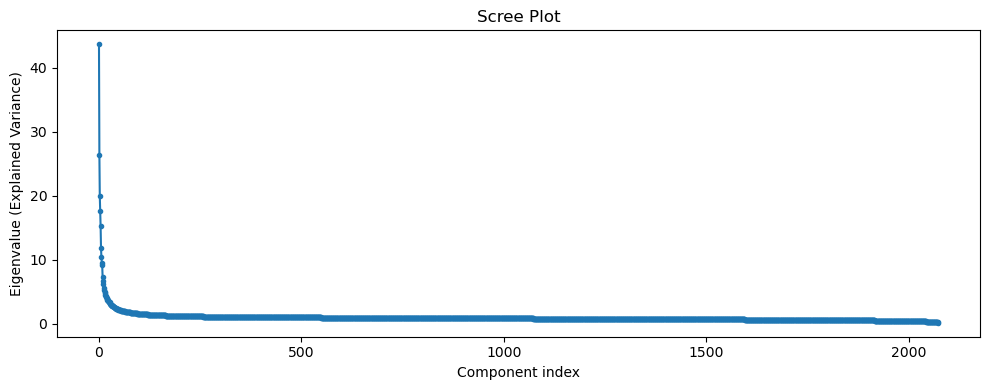

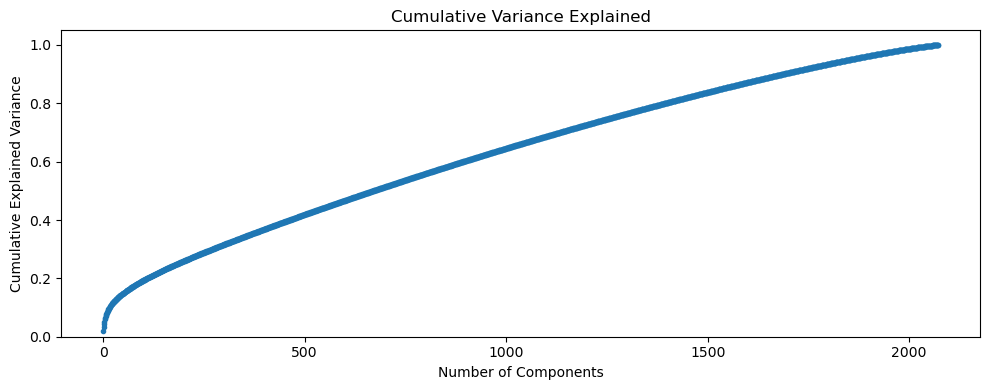

In [21]:
# Z-score each neuron
X_mean = X.mean(axis=1, keepdims=True)
X_std  = X.std(axis=1, keepdims=True) + 1e-9
X_z = (X - X_mean) / X_std   # shape: (n_units, n_bins)

# PCA
pca = PCA()
PCs = pca.fit_transform(X_z.T)   # (n_bins, n_components)
print("Total components:", PCs.shape[1])

eigvals = pca.explained_variance_
explained_var = pca.explained_variance_ratio_

# Scree Plot
plt.figure(figsize=(10,4))
plt.plot(eigvals, '-o', markersize=3)
plt.xlabel("Component index")
plt.ylabel("Eigenvalue (Explained Variance)")
plt.title("Scree Plot")
plt.tight_layout()
plt.show()

# Cumulative variance plot
plt.figure(figsize=(10,4))
plt.plot(np.cumsum(explained_var), '-o', markersize=3)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")
plt.ylim([0,1.05])
plt.tight_layout()
plt.show()
